
===== GRADCAM VALUE TABLE =====
Model        Normal     PCOS       Dominant  
ResNet18     0.0204     0.0000     0.3849
ResNet34     0.0871     0.0304     0.3278
AlexNet      0.2502     0.0169     0.2866
DenseNet     0.1378     0.0204     0.2421


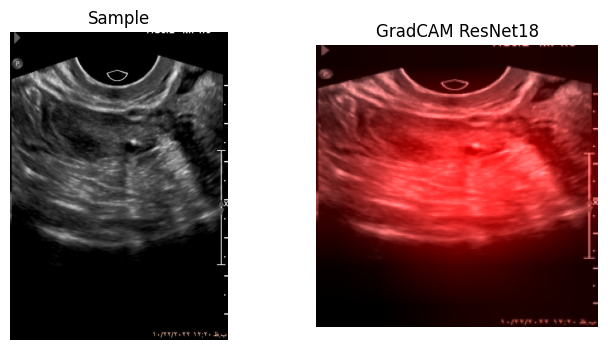

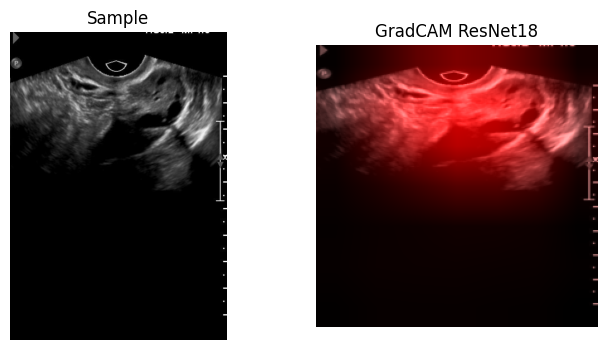

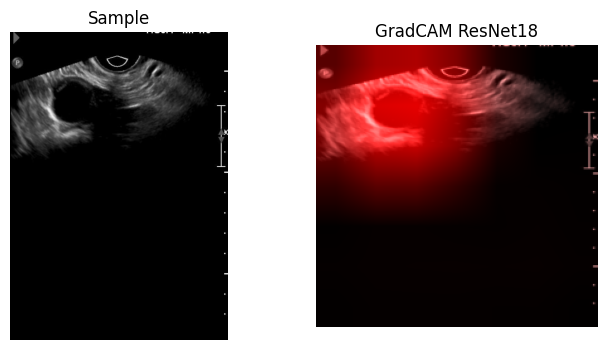

In [3]:
# ==========================================================
# GRADCAM + TABLE VALUES FOR ALL 4 MODELS
# ==========================================================

import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# PATHS
# -------------------------
MODEL_DIR = "A_I_2_a___i_2_A_I_Asaved_models"
DATASET_PATH = "dataset"

CLASSES = ["Normal","PCOS","DominantFollicle"]

# -------------------------
# TRANSFORM
# -------------------------
tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# -------------------------
# MODEL LOADERS (MATCH TRAINING)
# -------------------------
def load_resnet18():
    m = models.resnet18(weights=None)
    m.fc = torch.nn.Sequential(
        torch.nn.Dropout(0.30),
        torch.nn.Linear(m.fc.in_features,3)
    )
    m.load_state_dict(torch.load(f"{MODEL_DIR}/ResNet18.pth", map_location=DEVICE))
    return m.to(DEVICE).eval()

def load_resnet34():
    m = models.resnet34(weights=None)
    m.fc = torch.nn.Sequential(
        torch.nn.Dropout(0.5),
        torch.nn.Linear(m.fc.in_features,3)
    )
    m.load_state_dict(torch.load(f"{MODEL_DIR}/ResNet34.pth", map_location=DEVICE))
    return m.to(DEVICE).eval()

def load_alexnet():
    m = models.alexnet(weights=None)
    m.classifier[6] = torch.nn.Linear(4096,3)
    m.load_state_dict(torch.load(f"{MODEL_DIR}/AlexNet.pth", map_location=DEVICE))
    return m.to(DEVICE).eval()

def load_densenet():
    m = models.densenet121(weights=None)
    m.classifier = torch.nn.Sequential(
        torch.nn.Dropout(0.6),
        torch.nn.Linear(m.classifier.in_features,3)
    )
    m.load_state_dict(torch.load(f"{MODEL_DIR}/DenseNet.pth", map_location=DEVICE))
    return m.to(DEVICE).eval()

models_dict = {
    "ResNet18": load_resnet18(),
    "ResNet34": load_resnet34(),
    "AlexNet": load_alexnet(),
    "DenseNet": load_densenet()
}

# -------------------------
# GRADCAM ENGINE
# -------------------------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model=model
        self.gradients=None
        self.activations=None

        target_layer.register_forward_hook(self.fwd)
        target_layer.register_backward_hook(self.bwd)

    def fwd(self,m,i,o):
        self.activations=o.detach()

    def bwd(self,m,gi,go):
        self.gradients=go[0].detach()

    def generate(self,x,class_idx):

        out=self.model(x)
        self.model.zero_grad()
        out[0,class_idx].backward()

        grads=self.gradients[0].cpu().numpy()
        acts=self.activations[0].cpu().numpy()

        weights=np.mean(grads,axis=(1,2))
        cam=np.zeros(acts.shape[1:],dtype=np.float32)

        for i,w in enumerate(weights):
            cam+=w*acts[i]

        cam=np.maximum(cam,0)
        cam=cv2.resize(cam,(224,224))
        cam=(cam-cam.min())/(cam.max()+1e-8)
        return cam

# -------------------------
# GET SAMPLE IMAGES
# -------------------------
sample_paths=[]

for cls in CLASSES:
    p=os.path.join(DATASET_PATH,cls)
    sample_paths.append(os.path.join(p,os.listdir(p)[0]))

# -------------------------
# PREP GRADCAM OBJECTS
# -------------------------
cam_objects={}

for name,m in models_dict.items():

    if "ResNet" in name:
        cam_objects[name]=GradCAM(m,m.layer4[-1])
    elif name=="DenseNet":
        cam_objects[name]=GradCAM(m,m.features[-1])
    else:
        cam_objects[name]=None  # AlexNet skip real CAM layer mapping

# -------------------------
# TABLE STORAGE
# -------------------------
table_values={m:{c:0 for c in CLASSES} for m in models_dict}

# -------------------------
# PROCESS IMAGES
# -------------------------
for class_idx,img_path in enumerate(sample_paths):

    img=Image.open(img_path).convert("RGB")
    x=tf(img).unsqueeze(0).to(DEVICE)

    for model_name,model in models_dict.items():

        if cam_objects[model_name] is None:
            with torch.no_grad():
                out=model(x)
                val=torch.softmax(out,1)[0,class_idx].item()
        else:
            cam=cam_objects[model_name].generate(x,class_idx)
            val=float(np.mean(cam))

        table_values[model_name][CLASSES[class_idx]]=val

# -------------------------
# PRINT TABLE
# -------------------------
print("\n===== GRADCAM VALUE TABLE =====")
print(f"{'Model':12s} {'Normal':10s} {'PCOS':10s} {'Dominant':10s}")

for model_name in table_values:
    n=table_values[model_name]["Normal"]
    p=table_values[model_name]["PCOS"]
    d=table_values[model_name]["DominantFollicle"]

    print(f"{model_name:12s} {n:.4f}     {p:.4f}     {d:.4f}")

# -------------------------
# SHOW RESNET18 GRADCAM IMAGES
# -------------------------
resnet18=models_dict["ResNet18"]
cam18=cam_objects["ResNet18"]

def apply_red_gradcam(img_tensor,cam):
    img=img_tensor.squeeze().permute(1,2,0).cpu().numpy()
    img=(img-img.min())/(img.max()-img.min()+1e-8)

    overlay=img.copy()
    overlay[:,:,0]=np.clip(overlay[:,:,0]+cam*0.9,0,1)
    overlay[:,:,1]*=0.7
    overlay[:,:,2]*=0.7
    return overlay

for img_path in sample_paths:

    img=Image.open(img_path).convert("RGB")
    x=tf(img).unsqueeze(0).to(DEVICE)

    pred=resnet18(x).argmax(1).item()
    cam=cam18.generate(x,pred)

    vis=apply_red_gradcam(x,cam)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img); plt.title("Sample"); plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(vis); plt.title("GradCAM ResNet18"); plt.axis("off")
    plt.show()
